# Домашнее задание к занятию «Классификация: Логистическая регрессия и SVM»


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

    первый взгляд на данные

In [2]:
df = pd.read_csv('adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


### Проведите первичный анализ:
    a) проверьте данные на пропуски. Удалите в случае обнаружения.
    * Предложите альтернативный способ работы с пропусками
    b) постройте 1-2 графика на выбор. Визуализация должна быть основана на исследуемых данных и быть полезной (из графика можно сделать вывод об особенностях датасета/класса/признака)
    c) преобразуйте категориальные признаки



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [4]:
df.isna().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

    пропуски в виде знака "?". надо будет по другому их найти

In [5]:
(df == '?').sum() 

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

    меняю ? на НаН и удаляю пропуск. как вариант можно было заполнить модой. 

In [6]:
df = df.replace('?', np.nan).dropna()  

In [7]:
df.shape

(45222, 15)

In [8]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


In [9]:
(df == '?').sum() 

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [10]:
df.groupby('education')['educational-num'].unique()

education
10th             [6]
11th             [7]
12th             [8]
1st-4th          [2]
5th-6th          [3]
7th-8th          [4]
9th              [5]
Assoc-acdm      [12]
Assoc-voc       [11]
Bachelors       [13]
Doctorate       [16]
HS-grad          [9]
Masters         [14]
Preschool        [1]
Prof-school     [15]
Some-college    [10]
Name: educational-num, dtype: object

In [11]:
df['occupation'].value_counts()

occupation
Craft-repair         6020
Prof-specialty       6008
Exec-managerial      5984
Adm-clerical         5540
Sales                5408
Other-service        4808
Machine-op-inspct    2970
Transport-moving     2316
Handlers-cleaners    2046
Farming-fishing      1480
Tech-support         1420
Protective-serv       976
Priv-house-serv       232
Armed-Forces           14
Name: count, dtype: int64

In [12]:
df['fnlwgt'].nunique()

26741

In [13]:
# marital-status workclass occupation capital-gain capital-loss relationship educational-num income

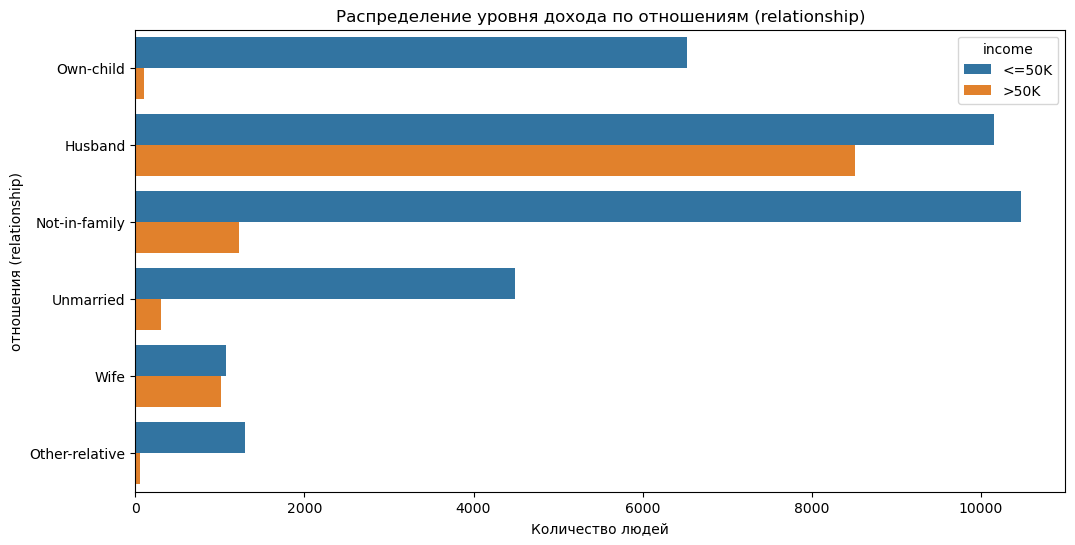

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(y='relationship', hue='income', data=df)
plt.title('Распределение уровня дохода по отношениям (relationship)')
plt.xlabel('Количество людей')
plt.ylabel('отношения (relationship)')
plt.show()

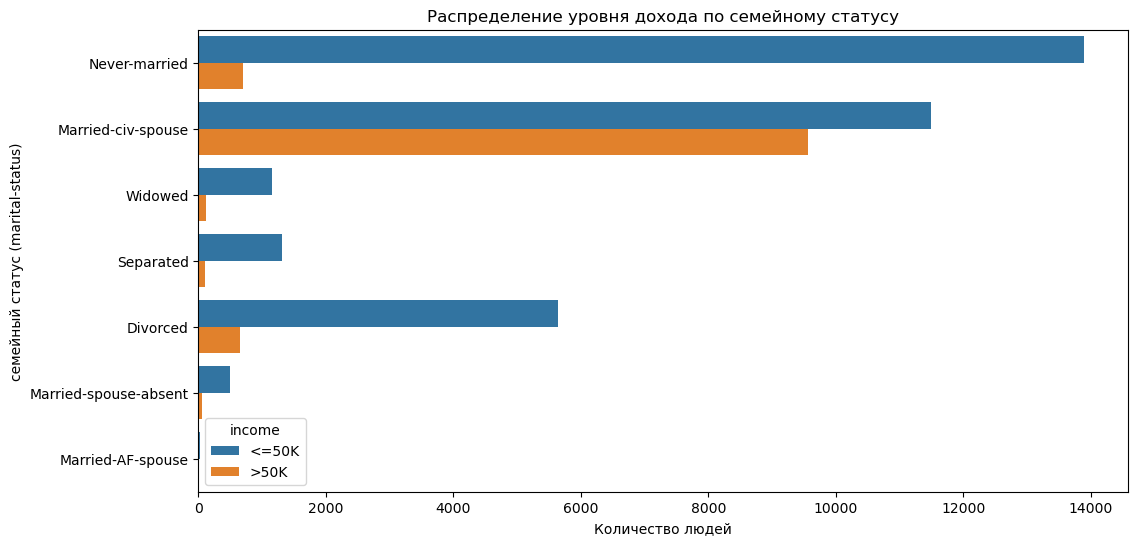

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(y='marital-status', hue='income', data=df)
plt.title('Распределение уровня дохода по семейному статусу')
plt.xlabel('Количество людей')
plt.ylabel('семейный статус (marital-status)')
plt.show()

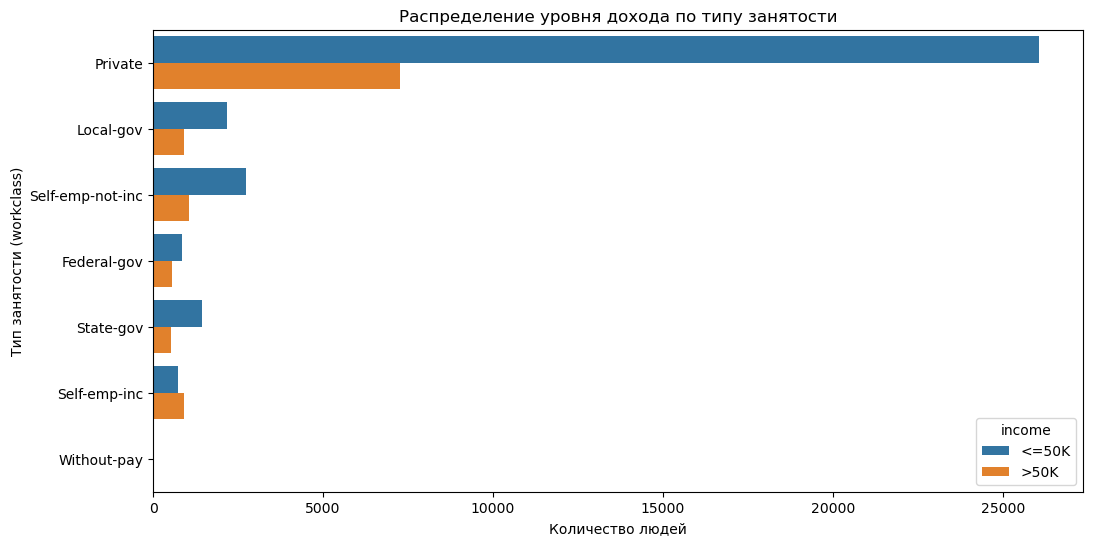

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(y='workclass', hue='income', data=df)
plt.title('Распределение уровня дохода по типу занятости')
plt.xlabel('Количество людей')
plt.ylabel('Тип занятости (workclass)')
plt.show()


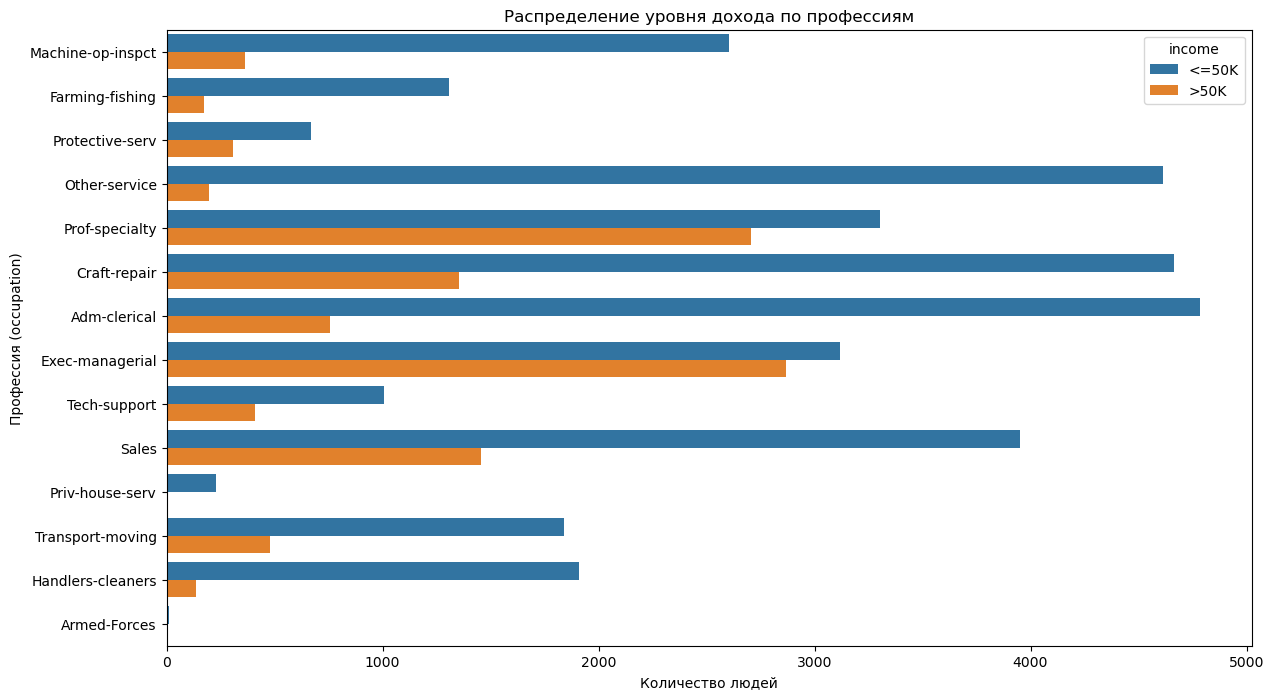

In [17]:
plt.figure(figsize=(14,8))
sns.countplot(y='occupation', hue='income', data=df)
plt.title('Распределение уровня дохода по профессиям')
plt.xlabel('Количество людей')
plt.ylabel('Профессия (occupation)')
plt.show()


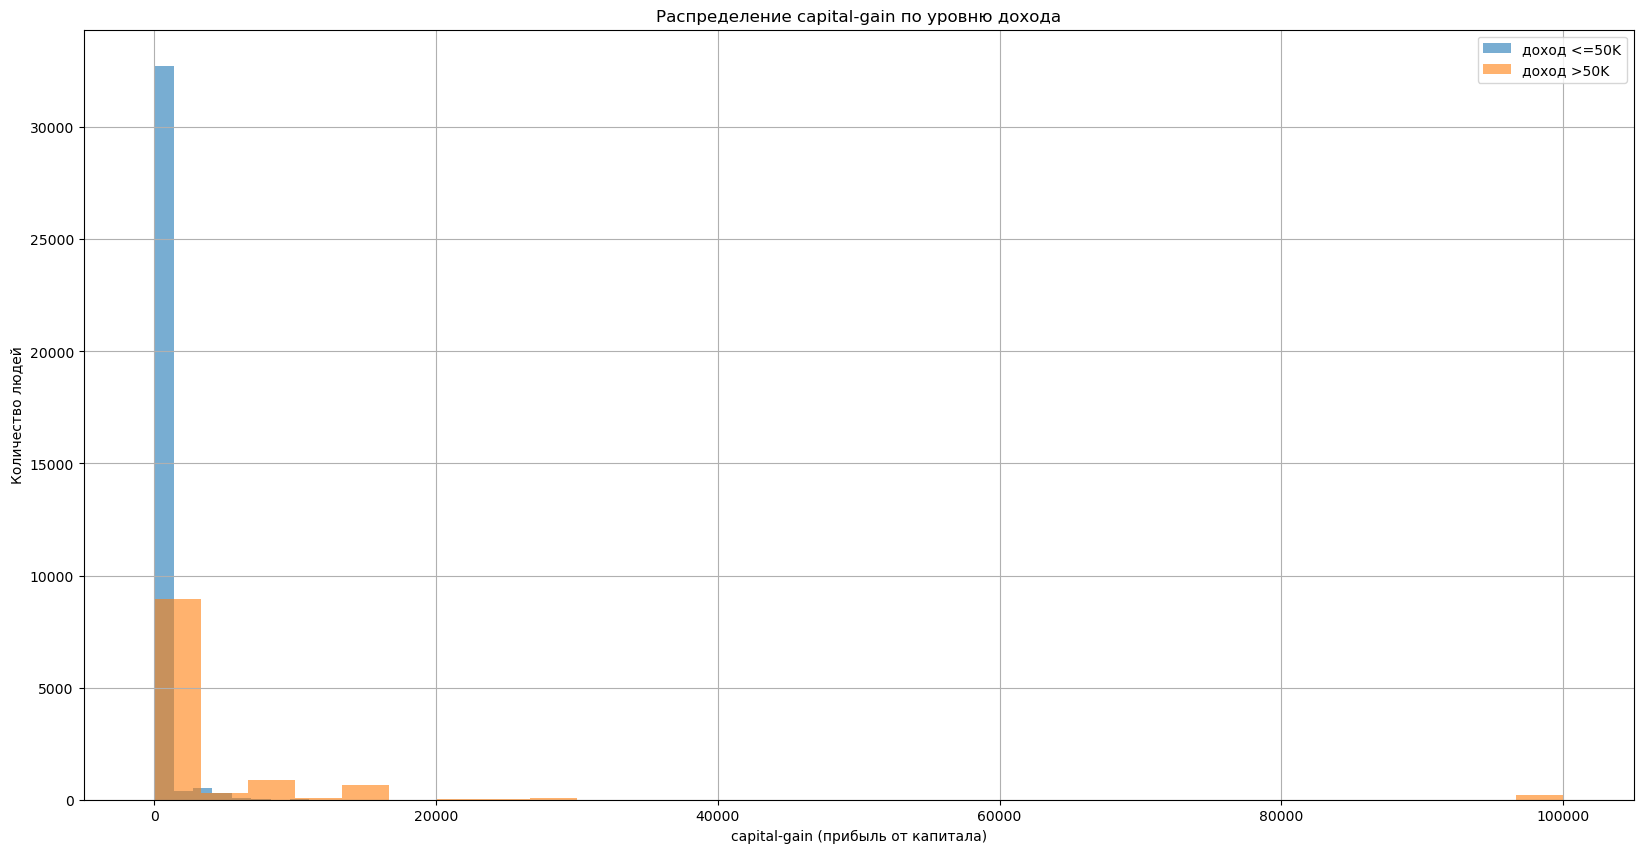

In [18]:
plt.figure(figsize=(20,10))
df[df['income']=='<=50K']['capital-gain'].hist(bins=30, alpha=0.6, label='доход <=50K')
df[df['income']=='>50K']['capital-gain'].hist(bins=30, alpha=0.6, label='доход >50K')
plt.xlabel('capital-gain (прибыль от капитала)')
plt.ylabel('Количество людей')
plt.legend()
plt.title('Распределение capital-gain по уровню дохода')
plt.show()


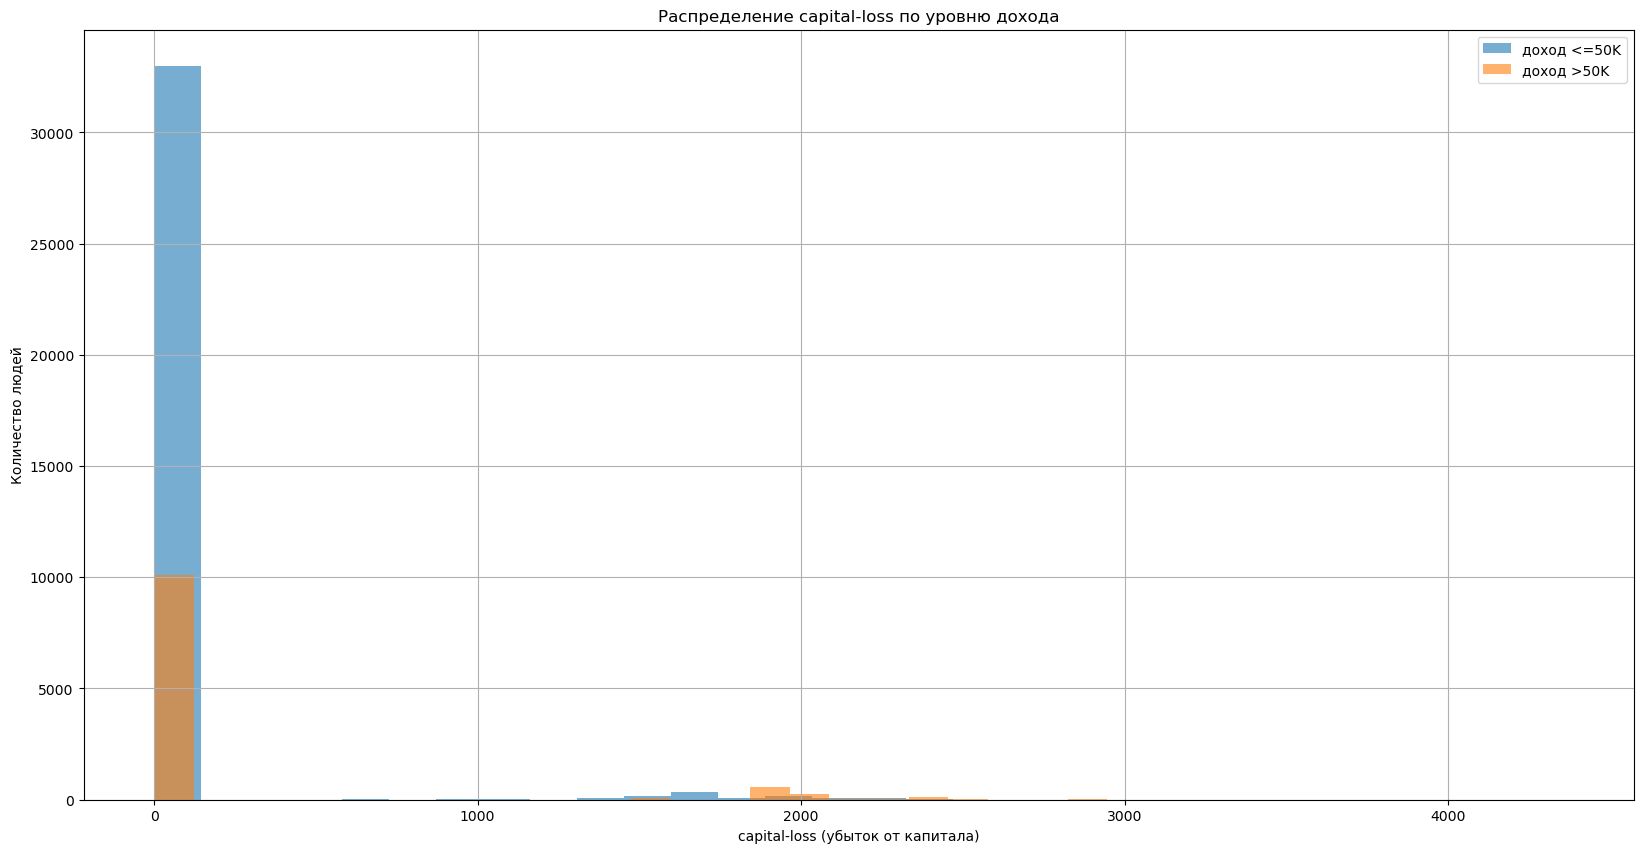

In [19]:
plt.figure(figsize=(20,10))
df[df['income']=='<=50K']['capital-loss'].hist(bins=30, alpha=0.6, label='доход <=50K')
df[df['income']=='>50K']['capital-loss'].hist(bins=30, alpha=0.6, label='доход >50K')
plt.xlabel('capital-loss (убыток от капитала)')
plt.ylabel('Количество людей')
plt.legend()
plt.title('Распределение capital-loss по уровню дохода')
plt.show()


In [20]:
selected_cols = ['marital-status', 'workclass', 'occupation', 
                 'capital-gain', 'capital-loss', 'relationship',
                 'educational-num', 'income']

df_selected = df[selected_cols].copy()
df_selected.head(2)

,marital-status,workclass,occupation,capital-gain,capital-loss,relationship,educational-num,income
0,Never-married,Private,Machine-op-inspct,0,0,Own-child,7,<=50K
1,Married-civ-spouse,Private,Farming-fishing,0,0,Husband,9,<=50K


In [21]:
df_for_model = pd.get_dummies(df_selected, 
                              columns=['marital-status', 'workclass', 'occupation', 'relationship'],
                              dtype='int',
                              drop_first=True)

In [22]:
df_for_model.head()

,capital-gain,capital-loss,educational-num,income,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,...,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,0,0,7,<=50K,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,9,<=50K,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,12,>50K,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,7688,0,10,>50K,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,6,<=50K,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0


In [23]:
X = df_for_model.drop('income',axis=1)
y = df_for_model.income

In [26]:
print(f'{X.shape} {y.shape} {df_for_model.shape}')

(45222, 33) (45222,) (45222, 34)


In [27]:
from sklearn.model_selection import train_test_split

# 20 процентов пойдет в тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [28]:
X_train.shape, X_test.shape


((36177, 33), (9045, 33))

In [29]:
36177 + 9045

45222

    Обучите модели логистической регрессии и опорных векторов на обучающем множестве.

    Для тестового множества предскажите уровень дохода и сравните с истинным значением, посчитав точность предсказания моделей. Для этого используйте встроенную функцию score.

    Сформулируйте выводы по проделанной работе:
    a) кратко опишите какие преобразования были сделаны с данными.
    b) cравните точность двух моделей.
    c) напишите свое мнение, в полной ли мере модели справились с поставленной задачей.
    * Что по вашему мнению нужно сделать, чтобы улучшить результат?

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

model = LogisticRegression(max_iter=700, random_state=42)
model_svm = SVC(random_state=42)

In [39]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=700, random_state=42)

In [40]:
model_svm.fit(X_train, y_train)


SVC(random_state=42)

In [41]:
y_pred = model.predict(X_test)

In [42]:
y_pred_svm = model_svm.predict(X_test)

In [46]:
accuracy = model.score(X_test, y_test)

In [45]:
accuracy_svm = model_svm.score(X_test, y_test)

In [48]:
accuracy, accuracy_svm

(0.8497512437810946, 0.7996683250414593)

# мои выводы
    что я делал.
    1) сделал первые импорты.
    2) прочитал данные, посмотрел на превые 5 строк, что бы понять вообще что там
    3) посмотрел info что бы увидеть какие типы данных у меня
    4) посмотрел пропуски. пропуски я не увидел и полез опять в описание датасета. и потом понял что 
    пропуски обозначены вопросителььным знаком
    5) удилил пропуски
    6) выбрал признаки которые я посчитал нужными
    7) посмотрел влияют ли они на income на графиках
    8) создал отдельный датафрейм с выбранными признаками
    9) преобразовал категориальные признаки исользуя One-Hot-Encoding(get_dummies)
    10) создал матрицу признаков и целевую переменную (икс и игрек)
    11) раздели на тест и трейн (80 на 20)
    12) импортировал модели 
    13) сначала у логистической регрессии была какая то ошибка, я нагуглил простое решение, увеличить количество итераций
    14) проверил точность моделей на тестовой выборке
    


    на этих признаках логистическая регрессия показала себя лучше. 85 процетов, не знаю хорошо это или плохо. Зависит все от бизнеса. Наверно можно как то улучшить результат, если выбрать другие модели, настроить какие нибудь параметры или обработать пропуски по другому, ну или использовать еще другие признаки. 